In [2]:
import pandas as pd
import numpy as np
import anytree
import matplotlib.pyplot as plt


## Analisis inical del dataset

In [3]:
dataset = pd.read_csv('dataset.csv')

In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [5]:
dataset.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [6]:
dataset.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

### Seleccionar las columnas requeridas para el proyecto

In [7]:
columnas_interesantes = ['Department',
                    'JobLevel',
                    'JobRole',
                    'MonthlyIncome',
                    'PerformanceRating',
                      'YearsAtCompany'
                    ]

In [8]:
dataset_interes = dataset[columnas_interesantes].copy()

In [9]:
dataset_interes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Department         1470 non-null   object
 1   JobLevel           1470 non-null   int64 
 2   JobRole            1470 non-null   object
 3   MonthlyIncome      1470 non-null   int64 
 4   PerformanceRating  1470 non-null   int64 
 5   YearsAtCompany     1470 non-null   int64 
dtypes: int64(4), object(2)
memory usage: 69.0+ KB


In [10]:
dataset_interes.sample(10)

,Department,JobLevel,JobRole,MonthlyIncome,PerformanceRating,YearsAtCompany
397,Sales,2,Sales Executive,4487,3,5
732,Research & Development,1,Laboratory Technician,2422,3,3
760,Sales,3,Sales Executive,7525,3,15
1220,Sales,2,Sales Representative,4502,3,13
36,Sales,1,Sales Representative,2683,3,3
1438,Sales,1,Sales Representative,1790,3,1
649,Research & Development,4,Research Director,14275,3,12
1102,Sales,1,Sales Representative,2644,4,3
342,Research & Development,3,Manufacturing Director,7143,3,11
292,Sales,1,Sales Representative,2789,3,2


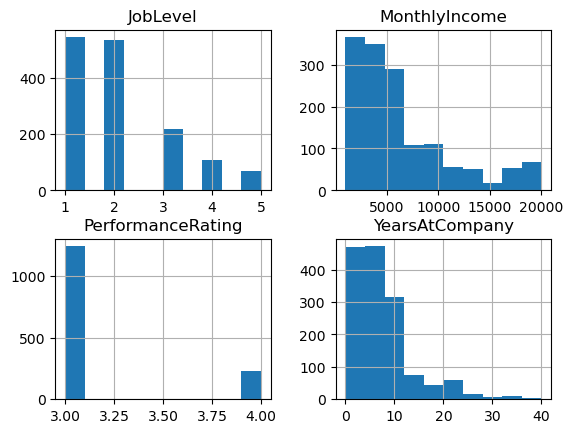

In [11]:
dataset_interes.hist();

### Observar la relacion etre Departamento, Roles y Niveles /
Parece ser q los los niveles concuerda con los roles, a excepcion del Rol de ResearchDirector que puede tener haste 3 niveles

In [12]:
dataset_interes.select_dtypes(include='object').value_counts()

Department              JobRole                  
Sales                   Sales Executive              326
Research & Development  Research Scientist           292
                        Laboratory Technician        259
                        Manufacturing Director       145
                        Healthcare Representative    131
Sales                   Sales Representative          83
Research & Development  Research Director             80
                        Manager                       54
Human Resources         Human Resources               52
Sales                   Manager                       37
Human Resources         Manager                       11
Name: count, dtype: int64

In [13]:
dataset_interes[['JobRole', 'JobLevel']].value_counts()

JobRole                    JobLevel
Research Scientist         1           234
Sales Executive            2           233
Laboratory Technician      1           200
Manufacturing Director     2            90
Sales Executive            3            79
Healthcare Representative  2            78
Sales Representative       1            76
Research Scientist         2            57
Laboratory Technician      2            56
Manager                    4            47
Manufacturing Director     3            45
Healthcare Representative  3            44
Manager                    5            43
Human Resources            1            33
Research Director          3            28
                           4            26
                           5            26
Sales Executive            4            14
Human Resources            2            13
Manager                    3            12
Manufacturing Director     4            10
Healthcare Representative  4             9
Sales Representati

## Construccion del sistema jerarquico en Forma de Arbol

In [14]:
from anytree import NodeMixin, RenderTree


### Definir clases para las entidades

In [ ]:

"""
(define (fn-for-empleado p)
  (... (empleado-rol p)
        (empleado-sueldo-mensual p)
        (empleado-nivel p)

       (fn-for-lo-empleados (empleados-subordinados p))))  ;mutual recursion from mutual-reference"""

def contar_subordinados(subs:list["Empleado"]):
  #print(len(subs))
  if len(subs) == 0:
    #print('zero')
    return 0

  else:
    primero = subs[0]
    #print(primero)
    #print(subs[1:])
    return 1 + primero.numero_de_subordinados() + contar_subordinados(subs[1:])

class Empleado(NodeMixin):
  def __init__(self, rol:str=None, sueldo_mensual:int=None, nivel:int=None) -> None:
    self.rol = rol
    self.sueldo_mensual = sueldo_mensual
    self.nivel = nivel
    #self.subordinados = subordinados if subordinados is not None else []
  def numero_de_subordinados(self):
    return contar_subordinados(self.children)
  def insertar_subordinado(self, un_subordinado:"Empleado"):
    # 1º Caso base: la diferencia de niveles == 1 , indica que es hijo directo
    if self.nivel - un_subordinado.nivel == 1:
      #self.subordinados.append(un_subordinado)
      un_subordinado.parent = self
      return True
      print('diferencia 1')
    # 2º Caso base: no hay diferencia de niveles, indica que es "hermano" ->
    if self.nivel == un_subordinado.nivel:
      un_subordinado.parent = self.parent
      return True
    # Caso recursivo: intentar insertarlo en alguno de los subordinados existentes
    for hijo in self.children:
        if hijo.insertar_subordinado(un_subordinado):
          #print('insertado en sub subordinado')
          return True
    #Caso si no hay subordinados y la difenrencia de niveles es mayor a 1
    un_subordinado.parent = self
    #print('insertado en subordniados n1')
    return True




class Departamento:
  def __init__(self, nombre_dpto:str, empleados: list[Empleado]) -> None:
    self.nombre = nombre_dpto
    self.empleados = empleados





In [35]:
# Ejemplo de uso
jefe = Empleado("Jefe", 5000, nivel=4)
medio = Empleado("medio", 2000, nivel=3)
bajo = Empleado("bajo", 1000, nivel=1)


In [36]:
jefe.insertar_subordinado(medio)
medio.insertar_subordinado(bajo)
jefe.numero_de_subordinados()

2

In [37]:
medio.insertar_subordinado(Empleado('bajo', 500, 1))

True

In [31]:
jefe.numero_de_subordinados()

3

In [32]:
from anytree import Node, RenderTree

In [33]:
for pre, fill, node in RenderTree(jefe):
    print("%s%s%i" % (pre, node.rol, node.nivel))

Jefe4
└── medio3
    ├── bajo1
    └── bajo1
